# Ex2 Q1: Log-linear classifier (TFIDF + single-layer perceptron)

In [1]:
# Imports + reproducibility + hyperparameters
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

from ex2 import get_data, category_dict
categories = list(category_dict.keys())

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available()
                      else ('mps' if torch.backends.mps.is_available() else 'cpu'))

epochs = 20
batch_size = 16
lr = 1e-3
feature_dim = 2000
num_labels = len(category_dict)

print(f'device: {device}')


device: mps


In [3]:
# Generalizable training + per-epoch validation
def train_and_eval(model, train_loader, test_loader, optimizer, criterion, epochs, device):
    train_losses, val_accs = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        train_losses.append(running / n)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_accs.append(correct / total)
        print(f'Epoch {epoch:02d} | train loss {train_losses[-1]:.4f} | val acc {val_accs[-1]:.4f}')
    return train_losses, val_accs


## (a) portion=0.1

In [4]:
# Data + TFIDF (portion=0.1)
portion = 0.1
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 229, test size: 1508


In [5]:
# Train (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_a, val_accs_a = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3823 | val acc 0.4741
Epoch 02 | train loss 1.3564 | val acc 0.5477
Epoch 03 | train loss 1.3331 | val acc 0.5862
Epoch 04 | train loss 1.3106 | val acc 0.6008
Epoch 05 | train loss 1.2884 | val acc 0.6207
Epoch 06 | train loss 1.2666 | val acc 0.6280
Epoch 07 | train loss 1.2452 | val acc 0.6466
Epoch 08 | train loss 1.2246 | val acc 0.6459
Epoch 09 | train loss 1.2037 | val acc 0.6618
Epoch 10 | train loss 1.1837 | val acc 0.6691
Epoch 11 | train loss 1.1641 | val acc 0.6790
Epoch 12 | train loss 1.1443 | val acc 0.6870
Epoch 13 | train loss 1.1256 | val acc 0.6890
Epoch 14 | train loss 1.1064 | val acc 0.6936
Epoch 15 | train loss 1.0886 | val acc 0.7009
Epoch 16 | train loss 1.0704 | val acc 0.7029
Epoch 17 | train loss 1.0528 | val acc 0.7115
Epoch 18 | train loss 1.0351 | val acc 0.7129
Epoch 19 | train loss 1.0183 | val acc 0.7115
Epoch 20 | train loss 1.0016 | val acc 0.7142


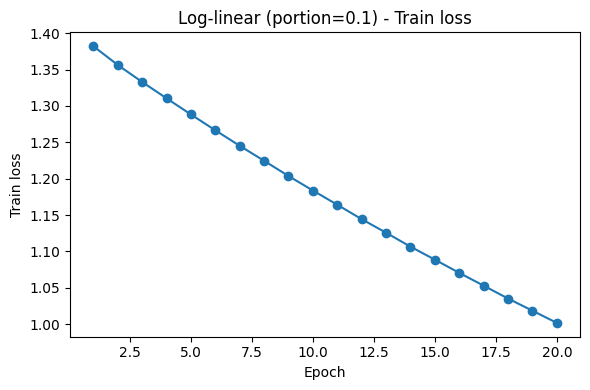

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_a, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'Log-linear (portion=0.1) - Train loss')
plt.tight_layout(); plt.show()


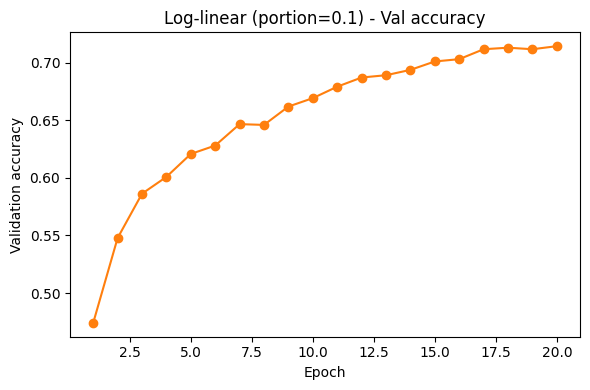

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_a, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'Log-linear (portion=0.1) - Val accuracy')
plt.tight_layout(); plt.show()


## (b) portion=0.2

In [8]:
# Data + TFIDF (portion=0.2)
portion = 0.2
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 451, test size: 1508


In [9]:
# Train (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_b, val_accs_b = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3755 | val acc 0.6167
Epoch 02 | train loss 1.3382 | val acc 0.6479
Epoch 03 | train loss 1.3043 | val acc 0.6094
Epoch 04 | train loss 1.2714 | val acc 0.6214
Epoch 05 | train loss 1.2399 | val acc 0.6393
Epoch 06 | train loss 1.2085 | val acc 0.6943
Epoch 07 | train loss 1.1788 | val acc 0.6976
Epoch 08 | train loss 1.1498 | val acc 0.7003
Epoch 09 | train loss 1.1218 | val acc 0.6963
Epoch 10 | train loss 1.0948 | val acc 0.7049
Epoch 11 | train loss 1.0680 | val acc 0.7109
Epoch 12 | train loss 1.0427 | val acc 0.7162
Epoch 13 | train loss 1.0182 | val acc 0.7248
Epoch 14 | train loss 0.9940 | val acc 0.7314
Epoch 15 | train loss 0.9707 | val acc 0.7401
Epoch 16 | train loss 0.9483 | val acc 0.7454
Epoch 17 | train loss 0.9263 | val acc 0.7447
Epoch 18 | train loss 0.9051 | val acc 0.7473
Epoch 19 | train loss 0.8841 | val acc 0.7460
Epoch 20 | train loss 0.8642 | val acc 0.7487


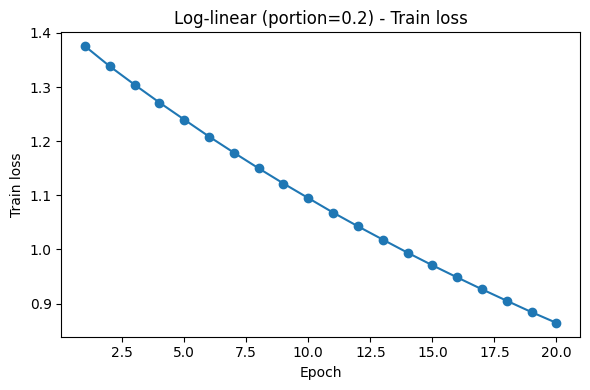

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_b, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'Log-linear (portion=0.2) - Train loss')
plt.tight_layout(); plt.show()


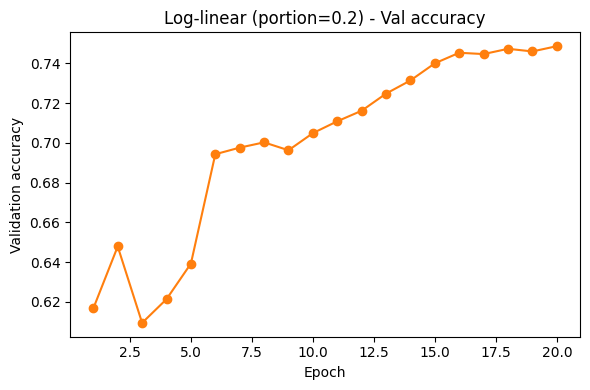

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_b, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'Log-linear (portion=0.2) - Val accuracy')
plt.tight_layout(); plt.show()


## (c) portion=0.5

In [12]:
# Data + TFIDF (portion=0.5)
portion = 0.5
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 1133, test size: 1508


In [13]:
# Train (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_c, val_accs_c = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3614 | val acc 0.5637
Epoch 02 | train loss 1.2958 | val acc 0.6850
Epoch 03 | train loss 1.2350 | val acc 0.7268
Epoch 04 | train loss 1.1772 | val acc 0.7653
Epoch 05 | train loss 1.1232 | val acc 0.7798
Epoch 06 | train loss 1.0718 | val acc 0.8011
Epoch 07 | train loss 1.0242 | val acc 0.8050
Epoch 08 | train loss 0.9792 | val acc 0.8064
Epoch 09 | train loss 0.9375 | val acc 0.8050
Epoch 10 | train loss 0.8979 | val acc 0.8090
Epoch 11 | train loss 0.8611 | val acc 0.8103
Epoch 12 | train loss 0.8267 | val acc 0.8156
Epoch 13 | train loss 0.7941 | val acc 0.8156
Epoch 14 | train loss 0.7638 | val acc 0.8183
Epoch 15 | train loss 0.7349 | val acc 0.8176
Epoch 16 | train loss 0.7081 | val acc 0.8203
Epoch 17 | train loss 0.6828 | val acc 0.8190
Epoch 18 | train loss 0.6590 | val acc 0.8223
Epoch 19 | train loss 0.6362 | val acc 0.8236
Epoch 20 | train loss 0.6151 | val acc 0.8223


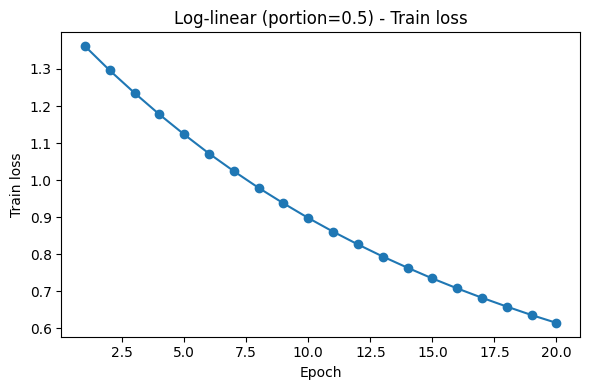

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_c, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'Log-linear (portion=0.5) - Train loss')
plt.tight_layout(); plt.show()


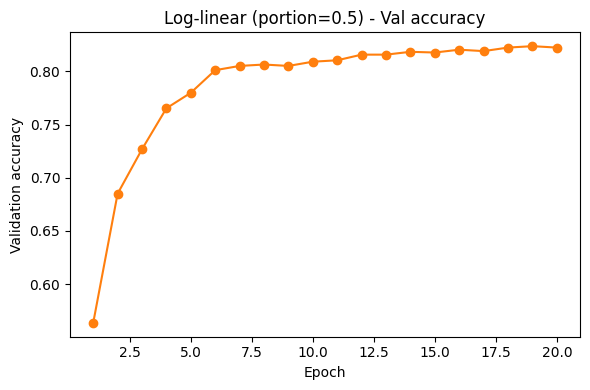

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_c, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'Log-linear (portion=0.5) - Val accuracy')
plt.tight_layout(); plt.show()


## (d) portion=1.0

In [16]:
# Data + TFIDF (portion=1.0)
portion = 1.0
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 2267, test size: 1508


In [17]:
# Train (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_d, val_accs_d = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3343 | val acc 0.7858
Epoch 02 | train loss 1.2248 | val acc 0.8156
Epoch 03 | train loss 1.1279 | val acc 0.8269
Epoch 04 | train loss 1.0419 | val acc 0.8349
Epoch 05 | train loss 0.9658 | val acc 0.8382
Epoch 06 | train loss 0.8984 | val acc 0.8395
Epoch 07 | train loss 0.8389 | val acc 0.8389
Epoch 08 | train loss 0.7859 | val acc 0.8435
Epoch 09 | train loss 0.7386 | val acc 0.8415
Epoch 10 | train loss 0.6963 | val acc 0.8448
Epoch 11 | train loss 0.6584 | val acc 0.8475
Epoch 12 | train loss 0.6239 | val acc 0.8481
Epoch 13 | train loss 0.5927 | val acc 0.8495
Epoch 14 | train loss 0.5642 | val acc 0.8481
Epoch 15 | train loss 0.5381 | val acc 0.8495
Epoch 16 | train loss 0.5142 | val acc 0.8501
Epoch 17 | train loss 0.4921 | val acc 0.8515
Epoch 18 | train loss 0.4716 | val acc 0.8528
Epoch 19 | train loss 0.4527 | val acc 0.8534
Epoch 20 | train loss 0.4349 | val acc 0.8528


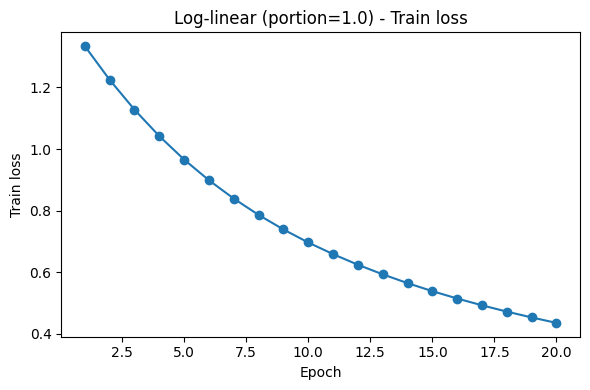

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_d, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'Log-linear (portion=1.0) - Train loss')
plt.tight_layout(); plt.show()


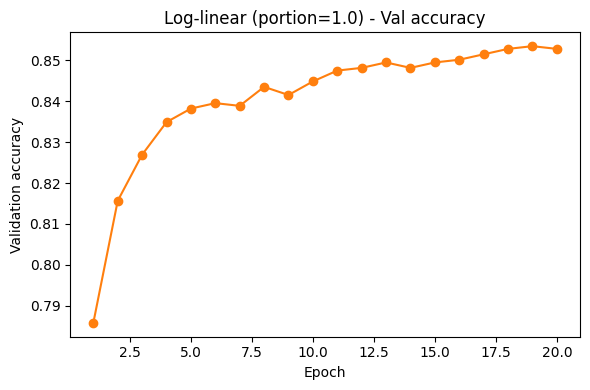

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_d, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'Log-linear (portion=1.0) - Val accuracy')
plt.tight_layout(); plt.show()
